# Investigates imapct of affinity dependent division rate



In [3]:
import numpy as np
import torch
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt
import os, warnings
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings("ignore", category=UserWarning,
                        message="KMP_DUPLICATE_LIB_OK")
import numpy as np


In [4]:

mu=0.001*3*40
p_sil=0.5*(mu)+(1-mu)
p_let=0.3*(mu)
p_aa=0.2*(mu)
E_a=np.log(40)                       
T=140
kBT=1                       # thermal factor
N_i=2500  
N_max=2500 
mu_i=0.0 
sigma_i=0.001*np.sqrt(40)
p_diff=0.10
c=170# 800, 1120, 920, 510

mu_M=-0.8
# sigma_M=1.09
sigma_M=1.68
# sigma_M=1.75

k_bonus=np.log(4)


    # ---------------- mutation statistics -------------------------------
f_aa  = p_aa / (p_aa + p_sil)
f_sil = 1.0 - f_aa
v_adv = f_aa * mu_M
D     = f_aa * (sigma_M**2 + f_sil * mu_M**2)
lam = np.log(2.0) + np.log1p(-p_let) + np.log1p(-p_diff)
S_mat=[[1.0]]
print(D)

0.0858041424906596


In [40]:


# ---------------------------------------------------------------------
# 1.  Run FP simulation  +  build Γ & ∇Γ lists
# ---------------------------------------------------------------------
def fp_density_time_series_kD(
    # biological / model parameters ---------------------------------------

    get_C=lambda t, v: 5.0,          # user-supplied concentration C_v(t)
    get_S=lambda t: S_mat,                      # shape (N_h, n_A) : s_{k,v} ∈ {±1}
    N_i=N_i,  N_max=N_max,
    # grid / time ----------------------------------------------------------
    h_min=-1.0, h_max=40.0, d_h=0.1,#d_h=0.05
    T=30.0,  dt=0.001,
    # output ---------------------------------------------------------------
    snapshot_interval=0.005,
    verbose=False,
    k_bonus=k_bonus,
    rho_c=0,                      # extinction threshold (cells per unit h-volume
):
    """
    Simulate k-dimensional GC Fokker–Planck dynamics in h-space.

    Parameters
    ----------
    S_mat : ndarray (N_h, n_A)
        Binary motif matrix: each column = antigen, each row = shape component.
    get_C : callable (t, v) → C_v(t)
        Returns surface concentration of antigen v at time t.
    """
    # ---------------- basic checks --------------------------------------
    if get_S is None:
        raise ValueError("S_mat (binary motif matrix) must be provided for each time step")
    N_h, n_A = get_S(0).shape          # k = dimension of h



    if D > 0.0:
        dt_max = d_h**2 / (2.0 * N_h * D)
        if dt > dt_max:
            raise ValueError(f"dt = {dt:.3g} exceeds CFL limit {dt_max:.3g}")


    # ---------------- k-dim Cartesian grid ------------------------------
    h_axis = np.arange(h_min, h_max + d_h, d_h)
    h_axes = (h_axis,) * N_h
    h_mesh = np.meshgrid(*h_axes, indexing="ij")      # list of length k
    dH     = d_h**N_h

    # ---------------- Gaussian initial population -----------------------
    g1d = np.exp(-(h_axis - mu_i) ** 2 / (2.0 * sigma_i**2))
    rho = np.prod(np.meshgrid(*([g1d] * N_h), indexing="ij"), axis=0)
    rho *= N_i / (rho.sum() * dH)

    snapshots = [rho.copy()]
    times     = [0.0]

    # ---------------- pre-allocate helper arrays ------------------------
    E_stack = np.zeros((n_A,) + rho.shape)           # energies  E_v(h)

    n_steps    = int(round(T / dt))
    snap_every = max(1, int(round(snapshot_interval / dt)))
    omegas=[0]
    # -------------------------------------------------------------------
    for step in range(1, n_steps + 1):
        t_now = step * dt
        N_pop = rho.sum() * dH

        # --- time-dependent concentrations -----------------------------
        C_vec  = np.array([get_C(t_now, v) for v in range(n_A)], dtype=float)
        C_tot  = C_vec.sum()

        # If no antigen is present, skip selection (pure drift/diffusion)
        if C_tot == 0.0:
            if verbose and step % snap_every == 0:
                print(f"{step:5d}  t={t_now:6.2f}  (no antigen present)")
            if step % snap_every == 0:
                snapshots.append(rho.copy());  times.append(t_now)
            continue

        # --- binding energies  E_v(h) ----------------------------------
        # S_mat.T : (n_A, N_h);  stacked h_mesh : (N_h, …grid…)
        S_mat=get_S(t_now)
        E_stack = np.tensordot(S_mat.T, np.stack(h_mesh, axis=0), axes=(1, 0))
        #            → shape (n_A, …grid…)

        # Broadcast C_v to all grid points
        C_broad = C_vec.reshape((n_A,) + (1,) * N_h)

        # --- antigen internalisation gate  P_Ag ------------------------
        exp_term  = np.exp((E_stack - E_a) / kBT)
        numer_PAg = (C_broad * exp_term).sum(axis=0)
        P_Ag      = numer_PAg / (1.0 + numer_PAg)

        # --- T‐cell help gate  P_T  (concentration-weighted) ----------
        eE   = np.exp(E_stack / kBT)
        Phi  =  eE.sum(axis=0)                 # Σ_v C_v e^{E_v/kBT}
        Phi_bar = (rho * Phi).sum() * dH / N_pop
        P_T  = Phi / (Phi + Phi_bar / C_tot)

        # --- growth/decay rate Γ(h,t) ----------------------------------
        log_sel = np.log(P_Ag) + np.log(P_T)
        avg_log = (rho * log_sel).sum() * dH / N_pop
        avg_P_Ag =(rho * P_Ag).sum() * dH / N_pop
        Omega   = 0.0 if N_pop < N_max+0.1 else max(0.0, lam + avg_log + k_bonus * avg_P_Ag)
        Gamma   = lam + log_sel - Omega + k_bonus * P_Ag

        # --- conservative flux divergence ------------------------------
        div_total = np.zeros_like(rho)
        for ax in range(N_h):
            rho_fwd  = np.roll(rho, -1, axis=ax)

            adv_flux  = v_adv * (rho if v_adv >= 0 else rho_fwd)
            diff_flux = -0.5 * D * (rho_fwd - rho) / d_h
            J_int     = adv_flux + diff_flux            # at cell interfaces

            # trim last cell (fwd neighbour outside domain)
            slc = [slice(None)] * N_h;  slc[ax] = slice(0, -1)
            J_int = J_int[tuple(slc)]

            # build full flux array with zero at boundaries
            J_shape = list(rho.shape); J_shape[ax] += 1
            J = np.zeros(J_shape)
            idx = [slice(None)] * N_h;  idx[ax] = slice(1, -1)
            J[tuple(idx)] = J_int

            div_total += np.diff(J, axis=ax) / d_h

        # --- explicit Euler update -------------------------------------
        rho += dt * (Gamma * rho - div_total)
        np.maximum(rho, 0.0, out=rho)                    # clip negatives
        cell_density = 1.0 / dH
        rho[rho < rho_c * cell_density] = 0.0

        # --- book-keeping ----------------------------------------------
        if step % snap_every == 0:
            snapshots.append(rho.copy())
            times.append(t_now)
            omegas.append(Omega)

        if verbose and step % snap_every == 0:
            mean_Gamma = (rho * Gamma).sum() * dH / N_pop
            mean_h = [(rho * h_mesh[ax]).sum() * dH / N_pop for ax in range(N_h)]
            mean_h_str = "  ".join(f"⟨h_{i+1}⟩={m:6.2f}" for i, m in enumerate(mean_h))
            print(f"{step:5d}  t={t_now:6.2f}  N={N_pop:8.1f}  Ω={Omega:7.3f}  "
                  f"⟨Γ⟩={mean_Gamma:8.3f}  {mean_h_str}")

    return h_axes, np.array(times), np.stack(snapshots), np.array(omegas)



In [41]:
def run_fp(get_S, get_C, *, T=20.0, verbose=False):
    """
    Returns a dict 'fp_ctx' with everything downstream functions need.
    """
    axes, times, rho_t, omegas = fp_density_time_series_kD(
        get_S=get_S, get_C=get_C, T=T, verbose=verbose
    )

    # ---------- Φ̄(t_k) --------------------------------------------
    N_h, n_A  = get_S(0).shape
    d_h       = axes[0][1] - axes[0][0]
    dH        = d_h**N_h
    h_mesh    = np.meshgrid(*axes, indexing="ij")

    Phi_bar = np.zeros_like(times, dtype=float)
    for k, t_now in enumerate(times):
        E_full    = np.tensordot(get_S(t_now).T, np.stack(h_mesh, axis=0), axes=(1, 0))

        C_vec = np.array([get_C(float(t_now), v) for v in range(n_A)])
        Phi   = ( np.exp(E_full/kBT)).sum(axis=0)
        rho   = rho_t[k]
        Phi_bar[k] = (rho * Phi).sum()*dH / (rho.sum()*dH)

    # ---------- Γ & ∇Γ snapshots (autograd) ------------------------
    gamma_list, grad_list = [], []

    for k, t_now in enumerate(times):
        Phi_b  = float(Phi_bar[k])
        S_torch = torch.tensor(get_S(t_now), dtype=torch.float64)

        omega  = float(omegas[k])
        C_vec  = np.array([get_C(float(t_now), v) for v in range(n_A)], dtype=float)
        C_t    = torch.tensor(C_vec, dtype=torch.float64)

        def γ(h_t, C_t=C_t, Phi_b=Phi_b, omega=omega):
            E_v  = torch.mv(S_torch.T, h_t)
            P_Ag = (C_t * torch.exp((E_v - E_a) / kBT)).sum()
            P_Ag = P_Ag / (1.0 + P_Ag)
            Phi  = torch.exp(E_v / kBT).sum()
            P_T  = Phi / (Phi + Phi_b / C_t.sum())
            return lam + torch.log(P_Ag) + torch.log(P_T) - omega

        def gγ_np(h_np, γ=γ):          # capture γ itself
            h_t = torch.tensor(h_np, requires_grad=True, dtype=torch.float64)
            γ(h_t).backward()
            return h_t.grad.numpy()

        gamma_list.append(γ)
        grad_list.append(gγ_np)

    return dict(
        axes=axes, times=times, rho_t=rho_t, omegas=omegas,
        Phi_bar=Phi_bar,
        gamma_list=gamma_list, grad_list=grad_list,
        get_S=get_S, get_C=get_C
    )



In [42]:
import numpy as np
import matplotlib.pyplot as plt

def plot_fp_density_time_dim(fp_ctx, dim=0, *,
                             disp_step=5, cmap="viridis",
                             sol=None, t_clip=5.0):
    """
    Heat-map of ρ(t, h_dim), with colour-bar max taken from times ≥ t_clip.

    Parameters
    ----------
    fp_ctx   : dict   – output of run_fp
    dim      : int    – which h-coordinate to show (0-based)
    disp_step: float  – x-tick spacing
    cmap     : str    – Matplotlib colormap
    sol      : BVPResult or None – optional trajectory overlay
    t_clip   : float  – ignore times < t_clip when computing vmax
    """
    axes, times, rho_t = fp_ctx["axes"], fp_ctx["times"], fp_ctx["rho_t"]
    N_h = len(axes)
    if not (0 <= dim < N_h):
        raise ValueError(f"dim must be in [0,{N_h-1}]")

    h_axis = axes[dim]

    # --- marginal over all dims except `dim` --------------------------
    marginal_axes = tuple(i + 1 for i in range(N_h) if i != dim)  # +1 for time
    dH = np.prod([(axes[i][1] - axes[i][0]) for i in range(N_h)
                  if i != dim]) if N_h > 1 else 1.0
    rho_marg = rho_t.sum(axis=marginal_axes) * dH                 # (n_t, n_h)

    # --- choose vmax from t ≥ t_clip ----------------------------------
    idx_start = np.searchsorted(times, t_clip)          # first t ≥ t_clip
    vmax_clip = rho_marg[idx_start:].max()

    # --- plot ----------------------------------------------------------
    plt.figure(figsize=(6, 5))
    im = plt.imshow(rho_marg.T, origin="lower", aspect="auto",
                    extent=[times[0], times[-1], h_axis[0], h_axis[-1]],
                    cmap=cmap, vmin=0.0, vmax=vmax_clip)

    plt.colorbar(im, label=rf"$\rho(t,h_{{{dim+1}}})$")
    plt.xlabel("Time", fontsize=14)
    plt.ylabel(rf"$h_{{{dim+1}}}$", fontsize=14)
    plt.title(rf"Density $\rho(t,h_{{{dim+1}}})$ ")

    plt.xticks(np.arange(times[0], times[-1] + 1e-9, disp_step))

    if sol is not None:
        plt.plot(sol.x, sol.y[dim], color="red", lw=1.4,
                 label=rf"least-action $h_{{{dim+1}}}(t)$")
        plt.legend()

    plt.tight_layout()
    plt.show()





In [43]:
import numpy as np
import copy
T=140
print(f"\nRunning FP simulation for T={T} seconds")
fp_ctx = run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=lambda t, v: 170.0,
    T=T,
    verbose=False
)


plot_fp_density_time_dim(fp_ctx, sol=None, disp_step=10, cmap="Greys_r")








Running FP simulation for T=140 seconds


KeyboardInterrupt: 

### Compute C* with one round of convergence

c*(t) at the FP snapshots:
t= 0.000  c*=22.3969
t= 0.005  c*=22.4001
t= 0.010  c*=22.4034
t= 0.015  c*=22.4066
t= 0.020  c*=22.4098


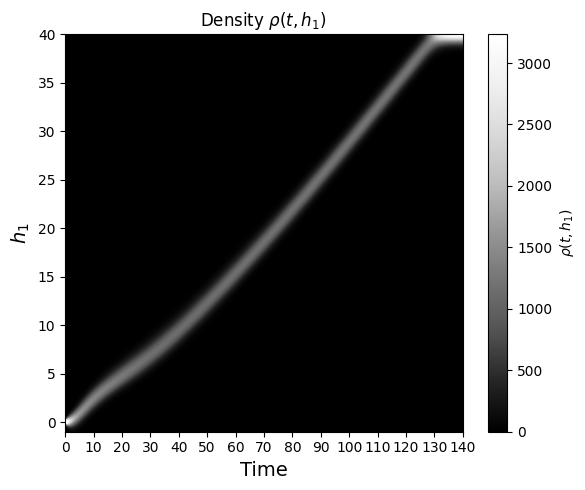

In [ ]:
import numpy as np

# ---------- grid measures (time-invariant) ----------
def _grid_measures(fp_ctx):
    axes  = fp_ctx["axes"]
    N_h   = len(axes)
    d_h   = axes[0][1] - axes[0][0]
    dH    = d_h ** N_h
    h_mesh = np.meshgrid(*axes, indexing="ij")  # list length N_h
    return axes, h_mesh, dH

# ---------- E_stack at a given time index k ----------
def _E_stack_at_k(fp_ctx, k, h_mesh):
    """
    Build E_stack_k[v, ...] = E_v(h, t_k) with S(t_k) from get_S.
    """
    times = fp_ctx["times"]
    get_S = fp_ctx["get_S"]                       # callable: t -> S_mat (N_h, n_A)
    S_k   = get_S(float(times[k]))                # (N_h, n_A)
    E_stack_k = np.tensordot(S_k.T, np.stack(h_mesh, axis=0), axes=(1, 0))
    # shape: (n_A, ...grid...)
    return E_stack_k

# ---------- ⟨log P_Ag + log P_T⟩_pop for a scalar C at time index k ----------
# ---------- ⟨log P_Ag + log P_T⟩_pop for a scalar C at time index k ----------
def avg_log_terms_given_C(C, k, fp_ctx, *, kBT, E_a):
    """
    Return <log P_Ag + log P_T>_pop, (P_Ag + P_T)_pop, <P_Ag>_pop, 
    and <P_Ag(1 - P_Ag)>_pop at snapshot k, assuming every antigen has 
    concentration C (scalar).
    """
    axes, h_mesh, dH = _grid_measures(fp_ctx)
    rho     = fp_ctx["rho_t"][k]                       # (...grid...)

    # time-dependent energies via get_S(t_k)
    E_stack = _E_stack_at_k(fp_ctx, k, h_mesh)         # (n_A, ...)

    n_A     = E_stack.shape[0]
    C_vec   = np.full(n_A, float(C), dtype=float)
    C_tot   = C_vec.sum()

    # P_Ag
    exp_term  = np.exp((E_stack - E_a) / kBT)                # (n_A, ...)
    numer     = (C_vec.reshape((n_A,) + (1,)*rho.ndim) * exp_term).sum(axis=0)
    P_Ag      = numer / (1.0 + numer)

    # P_T  (depends only on C_tot)
    Phi       = np.exp(E_stack / kBT).sum(axis=0)            # (...)

    # population-weighted averages
    N_pop     = rho.sum() * dH
    w_pop     = rho / N_pop

    # Gates

    # IMPORTANT: recompute Phi_bar for THIS s2
    Phi_bar  = (w_pop * Phi).sum() * dH
    P_T       = Phi / (Phi + Phi_bar / C_tot)

    avg_log   = (w_pop * (np.log(P_Ag) + np.log(P_T))).sum() * dH
    P_sum_pop = (w_pop * (P_Ag + P_T)).sum() * dH
    
    # New terms for the affinity-dependent cell division
    P_Ag_pop  = (w_pop * P_Ag).sum() * dH
    P_Ag_deriv_pop = (w_pop * P_Ag * (1.0 - P_Ag)).sum() * dH
    
    return avg_log, P_sum_pop, P_Ag_pop, P_Ag_deriv_pop

# ---------- solve c*(t_k) for all snapshots ----------
def solve_c_star_over_time(fp_ctx, *, lam=1.0, k_bonus=0.0, kBT, E_a,
                           u0=np.log(1.0), newton_maxit=5, newton_tol=1e-10):
    """
    For each k, solve for c* > 0 such that
        lam + k_bonus * <P_Ag>_pop + <log P_Ag + log P_T>_pop(C=c*) = 0
    with time-varying S(t_k).
    Newton in u=log C, derivative: 
    d/du (Gamma_pop) = k_bonus * <P_Ag(1 - P_Ag)>_pop + 2 - (P_Ag+P_T)_pop.
    """
    times  = fp_ctx["times"]
    K      = len(times)
    c_star = np.empty(K, dtype=float)

    for k in range(K):
        u = float(u0)
        for it in range(newton_maxit):
            avg_log, Psum, P_Ag_pop, P_Ag_deriv_pop = avg_log_terms_given_C(np.exp(u), k, fp_ctx, kBT=kBT, E_a=E_a)
            
            # Updated function g(u) = 0
            g  = avg_log + lam + k_bonus * P_Ag_pop
            
            if abs(g) < newton_tol:
                break
                
            # Updated derivative dg/du
            dg = 2.0 - Psum + k_bonus * P_Ag_deriv_pop
            
            step = g / (dg if abs(dg) > 1e-8 else np.sign(dg)*1e-8)
            u   -= step
        else:
            # fallback: bracketing + bisection
            def F(u_): 
                res = avg_log_terms_given_C(np.exp(u_), k, fp_ctx, kBT=kBT, E_a=E_a)
                return res[0] + lam + k_bonus * res[2]
                
            u_lo, u_hi = u - 20.0, u + 20.0
            g_lo, g_hi = F(u_lo), F(u_hi)
            tries = 0
            while g_lo * g_hi > 0 and tries < 30:
                u_lo -= 5.0; u_hi += 5.0
                g_lo, g_hi = F(u_lo), F(u_hi); tries += 1
            for _ in range(10):
                u_mid = 0.5*(u_lo+u_hi); g_mid = F(u_mid)
                if g_mid > 0: u_hi = u_mid
                else:         u_lo = u_mid
            u = 0.5*(u_lo+u_hi)

        c_star[k] = np.exp(u)

    return np.array(times), c_star

times, c_star = solve_c_star_over_time(fp_ctx, lam=lam, kBT=kBT, E_a=E_a, k_bonus=k_bonus)
print("c*(t) at the FP snapshots:")
for t, c in zip(times[:5], c_star[:5]):
    print(f"t={t:6.3f}  c*={c:.6g}")

def make_get_C_from_cstar(times, c_star):
    times = np.asarray(times, dtype=float)
    c_star = np.asarray(c_star, dtype=float)
    t0, tf = float(times[0]), float(times[-1])

    def get_C_star(t, v):
        # same concentration for all antigens v
        t = float(t)
        if t <= t0:
            return float(c_star[0])
        if t >= tf:
            return float(c_star[-1])
        return float(np.interp(t, times, c_star))
    return get_C_star

get_C_star = make_get_C_from_cstar(times, c_star)

fp_ctx = run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=get_C_star,
    T=T,
    verbose=False
)


plot_fp_density_time_dim(fp_ctx, sol=None, disp_step=10, cmap="Greys_r")






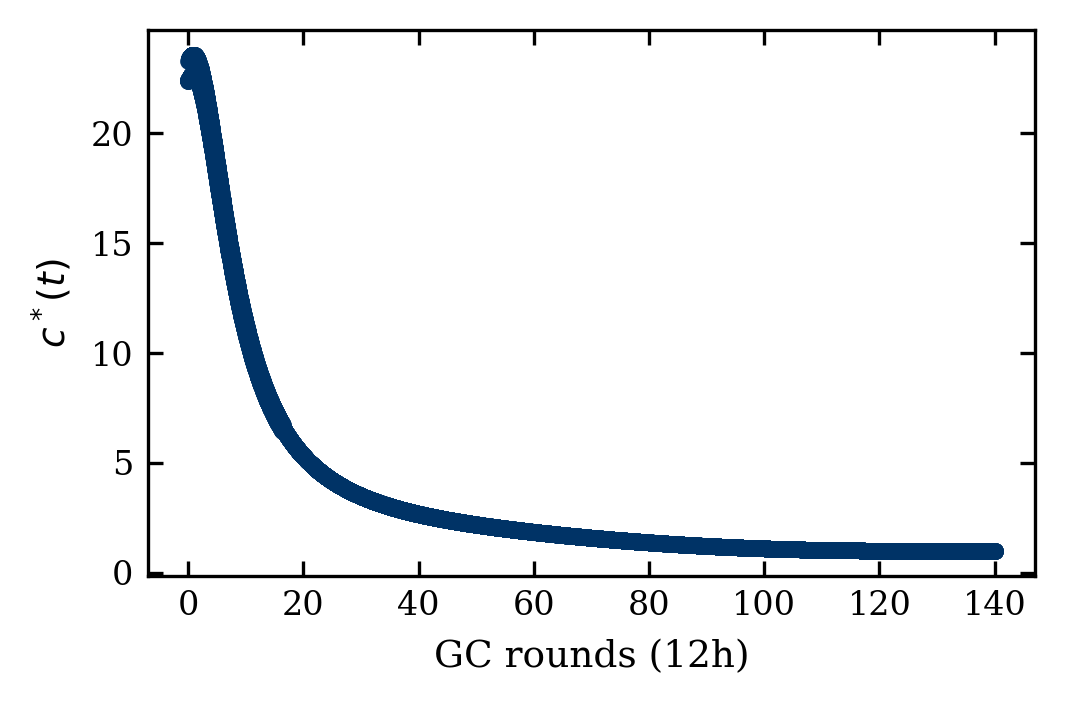

In [ ]:
import matplotlib.pyplot as plt

# 1. Apply the publication-ready formatting style
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.markersize": 3,
    "figure.figsize": (3.4, 2.2),  # Keeping your requested aspect ratio
    "figure.dpi": 300,
    "font.family": "serif",
})

# 2. Create Figure and Axes
fig, ax = plt.subplots()

# 3. Plot the data
# Using the "Navy Blue" from the previous palette for consistency
ax.plot(times, c_star, 
        marker='o', 
        markersize=3, 
        linewidth=1.0, 
        color='#003366',  # Professional dark blue
        label=r"$c^*(t)$")

# 4. Set Labels
ax.set_xlabel(r"GC rounds (12h)")
ax.set_ylabel(r"$c^*(t)$")

# 5. Apply aesthetic preferences (ticks in, no grid)
ax.tick_params(direction="in", top=True, right=True)
ax.grid(False)

# 6. Layout and Save
plt.tight_layout(pad=0.2)
# plt.savefig("c_star_vs_time.pdf")  # Uncomment to save
plt.show()


### Compute C* with multiple rounds of convergence

In [ ]:
import numpy as np



def iterate_fp_and_cstar(initial_fp_ctx, num_iterations, T, lam, kBT, E_a):
    """
    Alternates between solving for the optimal concentration C*(t) and 
    running the Fokker-Planck solver to find the new trajectory/distribution.
    """
    c_star_history = []
    fp_ctx = initial_fp_ctx
    
    for i in range(num_iterations):
        # 1. Obtain optimal concentration from the current FP context
        times, c_star = solve_c_star_over_time(fp_ctx, lam=lam, kBT=kBT, E_a=E_a)
        
        # Save the result for plotting convergence later
        c_star_history.append((times.copy(), c_star.copy()))
        
        print(f"Iteration {i+1}/{num_iterations} complete.")
        
        # 2. Create the interpolation function for the next FP run
        get_C_star = make_get_C_from_cstar(times, c_star)
        
        # 3. Run the Fokker-Planck solver with the updated concentration profile
        fp_ctx = run_fp(
            get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h1 and h2
            get_C=get_C_star,
            T=T,
            verbose=False
        )
        
    return c_star_history, fp_ctx

# Example usage:
num_iterations = 10
fp_ctx_init = run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=lambda t, v: 170.0,
    T=T,
    verbose=False
)
c_star_history, fp_ctx_star = iterate_fp_and_cstar(fp_ctx_init, num_iterations, T=T, lam=lam, kBT=kBT, E_a=E_a)
#plot



Iteration 1/10 complete.
Iteration 2/10 complete.
Iteration 3/10 complete.
Iteration 4/10 complete.
Iteration 5/10 complete.
Iteration 6/10 complete.
Iteration 7/10 complete.
Iteration 8/10 complete.
Iteration 9/10 complete.
Iteration 10/10 complete.


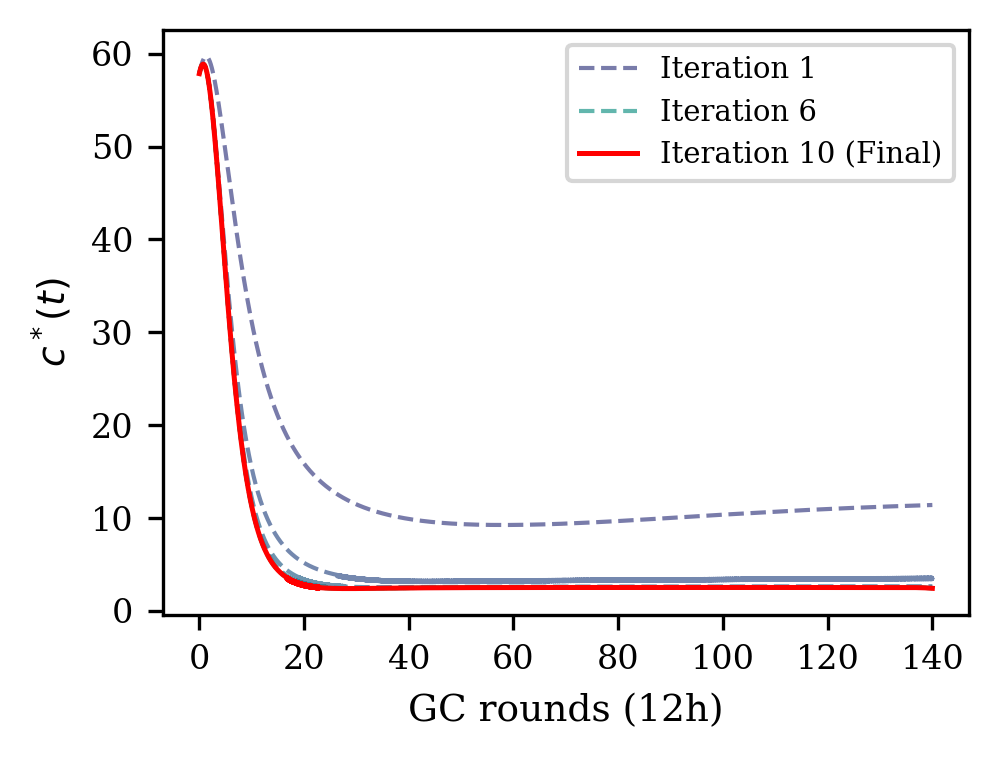

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_c_star_convergence(c_star_history):
    """Generates a plot showing the convergence of optimal concentration c*(t)."""
    
    # Global Style Settings
    plt.rcParams.update({
        "font.size": 9,
        "axes.labelsize": 9,
        "axes.titlesize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "lines.markersize": 3,
        "figure.figsize": (3.4, 2.6), # Standard column width
        "figure.dpi": 300,
        "font.family": "serif",
    })

    fig, ax = plt.subplots()
    
    num_iters = len(c_star_history)
    # Generate a sequence of colors to visualize progression
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, num_iters))
    
    for i, (times, c_star) in enumerate(c_star_history):
        # Visually distinct styling for the final convergence iteration
        if i == num_iters - 1:
            ax.plot(times, c_star, color='red', marker='', linestyle='-', 
                    linewidth=1.2, label=f"Iteration {i+1} (Final)", zorder=3)
        else:
            # Intermediate iterations fade from dark to light
            ax.plot(times, c_star, color=colors[i], marker='', linestyle='--', 
                    linewidth=1.0, alpha=0.7, label=f"Iteration {i+1}", zorder=2)

    ax.set_xlabel(r"GC rounds (12h)")
    ax.set_ylabel(r"$c^*(t)$")
    
    # Optional styling adjustments based on your reference
    # ax.tick_params(direction="in", top=True, right=True)
    ax.grid(False)
    
    # Prevent legend clutter if there are many iterations
    if num_iters <= 5:
        ax.legend(frameon=True, loc='best', fontsize=7)
    else:
        # Show first, middle, and last iteration in legend
        handles, labels = ax.get_legend_handles_labels()
        display_indices = [0, num_iters // 2, -1]
        ax.legend([handles[j] for j in display_indices], 
                  [labels[j] for j in display_indices], 
                  frameon=True, loc='best', fontsize=7)

    plt.tight_layout()
    plt.show()

# Example usage:
plot_c_star_convergence(c_star_history)
c_star=c_star_history[-1][1]


### Study the effect of c on the optimal schedule and optimal antigen

In [47]:
times.shape#(28001,)
c_star.shape#(28001,)
#save as a csv
import pandas as pd

df = pd.DataFrame({"time": times, "c_star": c_star})
df.to_csv("c_star_over_time_k_bonus.csv", index=False)


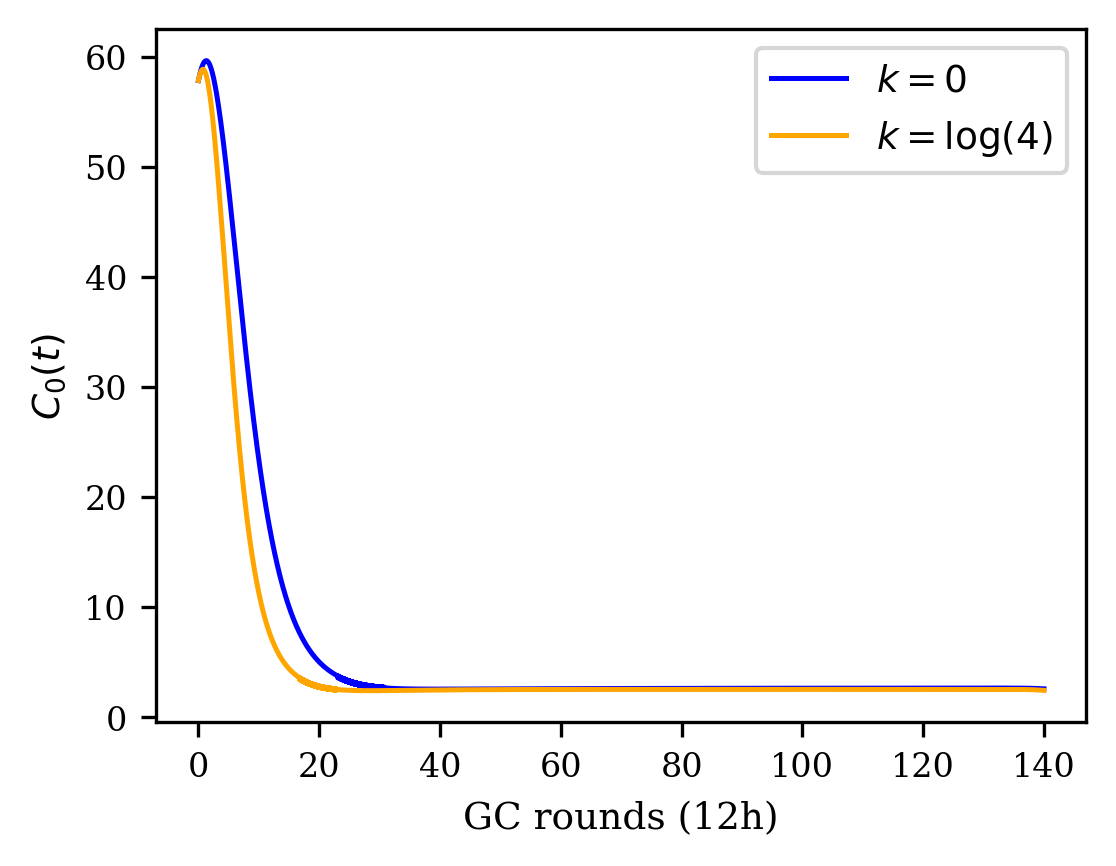

In [48]:
df_cstar=pd.read_csv("c_star_over_time.csv")
df_cstar_k_bonus_0 = pd.read_csv("c_star_over_time_k_bonus.csv")


plt.figure(figsize=(4, 3), dpi=300)
plt.plot(df_cstar["time"], df_cstar["c_star"], label=r"$k=0$", color='blue', linewidth=1.2)
plt.plot(df_cstar_k_bonus_0["time"], df_cstar_k_bonus_0["c_star"], label=r"$k=\log(4)$", color='orange', linewidth=1.2)
plt.xlabel(r"GC rounds (12h)")
plt.ylabel(r"$C_0(t)$")
plt.legend()

# Injection optim

In [49]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

class ImmunizationOptimizer(nn.Module):
    def __init__(self, N, tau, initial_C_values, initial_interval_values):
        super().__init__()
        self.N = N
        self.tau = float(tau)
        
        # Helper for inverse softplus: x = ln(exp(y) - 1)
        def inverse_softplus(y):
            return np.log(np.exp(y) + 1e-6 - 1)

        # 1. Parameter for Concentrations (log_C)
        # We initialize in log space. max() ensures we don't take log of 0 or negative numbers.
        init_log_C = [np.log(max(val, 1e-8)) for val in initial_C_values]
        self.log_C = nn.Parameter(torch.tensor(init_log_C, dtype=torch.float32))
        
        # 2. Parameter for Time Intervals (dt)
        if N > 1:
            init_dt_raw = [inverse_softplus(val) for val in initial_interval_values]
            self.raw_dt = nn.Parameter(torch.tensor(init_dt_raw, dtype=torch.float32))
        else:
            self.raw_dt = None

    def get_physical_parameters(self):
        # Ensure Positive Concentrations by taking the exponential of the log parameter
        C_i = torch.exp(self.log_C)
        
        # Construct Times from Intervals
        t_1 = torch.tensor([0.0], device=self.log_C.device)
        if self.N > 1:
            intervals = torch.nn.functional.softplus(self.raw_dt)
            later_times = torch.cumsum(intervals, dim=0)
            t_i = torch.cat([t_1, later_times])
        else:
            t_i = t_1
            
        return C_i, t_i

    def forward(self, t_eval, sigmoid_steepness=50.0):
        C_i, t_i = self.get_physical_parameters()
        
        t_eval = t_eval.view(-1, 1)
        t_i = t_i.view(1, -1)
        C_i = C_i.view(1, -1)
        
        dt = t_eval - t_i
        
        # Differentiable Step Function
        step_approx = torch.sigmoid(sigmoid_steepness * dt)
        
        # FIX: Use ReLU to prevent exponential explosion for t < t_i
        # It forces the decay term to 1.0 before the injection, which is then 
        # safely zeroed out by the step_approx multiplier.
        safe_dt = torch.relu(dt)
        decay = torch.exp(-safe_dt / self.tau)
        
        concentration_matrix = step_approx * C_i * decay
        C_total = torch.sum(concentration_matrix, dim=1)
        
        return C_total


def find_optimal_parameters(N, tau, t_eval_array, C_star_array, epochs=4000, lr=0.1):
    # Base interval assumption for initialization
    interval_guess = 20.0
    init_intervals = [interval_guess] * (N - 1)
    init_C_values = []
    
    for i in range(N):
        expected_time = i * interval_guess
        idx = (np.abs(t_eval_array - expected_time)).argmin()
        
        # Get the target value at this time step
        target_val = max(float(C_star_array[idx]), 1e-4)
        
        # Analytically scale the initialization to prevent underdose during the interval
        # C_initial = C_target * exp(dt / tau)
        safe_val = target_val * np.exp(interval_guess / tau)
        
        init_C_values.append(safe_val)

    t_tensor = torch.tensor(t_eval_array, dtype=torch.float32)
    C_star_tensor = torch.tensor(C_star_array, dtype=torch.float32)
    
    model = ImmunizationOptimizer(N, tau, init_C_values, init_intervals)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # --- Barrier Hyperparameters ---
    # barrier_weight (lambda): Scales the overall impact of the penalty.
    # barrier_steepness (gamma): Controls how fast the wall shoots up.
    barrier_weight = 100.0  
    barrier_steepness = 10.0 

    for epoch in range(epochs):
        optimizer.zero_grad()
        
        # Annealing
        current_steepness = 10.0 + (90.0 * epoch / epochs)
        
        C_simulated = model(t_tensor, sigmoid_steepness=current_steepness)
        
        # Compute Log Difference
        log_C_simulated = torch.log(C_simulated + 1e-8)
        log_C_star = torch.log(C_star_tensor + 1e-8)
        
        # 1. Base MSE (handles general curve fitting and over-dosing)
        mse_loss = torch.mean((log_C_simulated - log_C_star) ** 2)
        
        # 2. Exponential Barrier (handles under-dosing)
        # ReLU ensures this is only > 0 when C_simulated < C_star
        underdose_amount = torch.relu(log_C_star - log_C_simulated)
        
        # Clamp the underdose amount to prevent exponential overflow (NaNs) early in training
        underdose_amount_clamped = torch.clamp(underdose_amount, max=5.0)
        
        # barrier_penalty = torch.mean(barrier_weight * (torch.exp(barrier_steepness * underdose_amount_clamped) - 1.0))
        mse_underdose=torch.mean(underdose_amount_clamped ** 2)* barrier_weight
        # Combine losses
        loss = mse_loss + mse_underdose

        loss.backward()
        
        # Gradient clipping is crucial here so the exponential penalty doesn't destabilize Adam
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        
        optimizer.step()

    final_C, final_t = model.get_physical_parameters()
    
    return {
        "C_optimized": final_C.detach().numpy(),
        "t_optimized": final_t.detach().numpy(),
        "final_loss": loss.item(),
        'C_simulated': C_simulated.detach().numpy()
    }

In [50]:
N_injections = 1
tau_val = 20.0

result1 = find_optimal_parameters(N_injections, tau_val, times, c_star)

print("\nFinal Result:")
print("Optimized Injections (C):", result1['C_optimized'])
print("Optimized Times (t):", result1['t_optimized'])

N_injections = 2
tau_val = 20.0

result2 = find_optimal_parameters(N_injections, tau_val, times, c_star)

print("\nFinal Result:")
print("Optimized Injections (C):", result2['C_optimized'])
print("Optimized Times (t):", result2['t_optimized'])

N_injections = 3
tau_val = 20.0

result3 = find_optimal_parameters(N_injections, tau_val, times, c_star)

print("\nFinal Result:")
print("Optimized Injections (C):", result3['C_optimized'])
print("Optimized Times (t):", result3['t_optimized'])




Final Result:
Optimized Injections (C): [1498.759]
Optimized Times (t): [0.]

Final Result:
Optimized Injections (C): [79.16255  46.634193]
Optimized Times (t): [ 0.       74.828125]

Final Result:
Optimized Injections (C): [54.93888  11.664456 11.668039]
Optimized Times (t): [  0.       65.02933 102.37938]


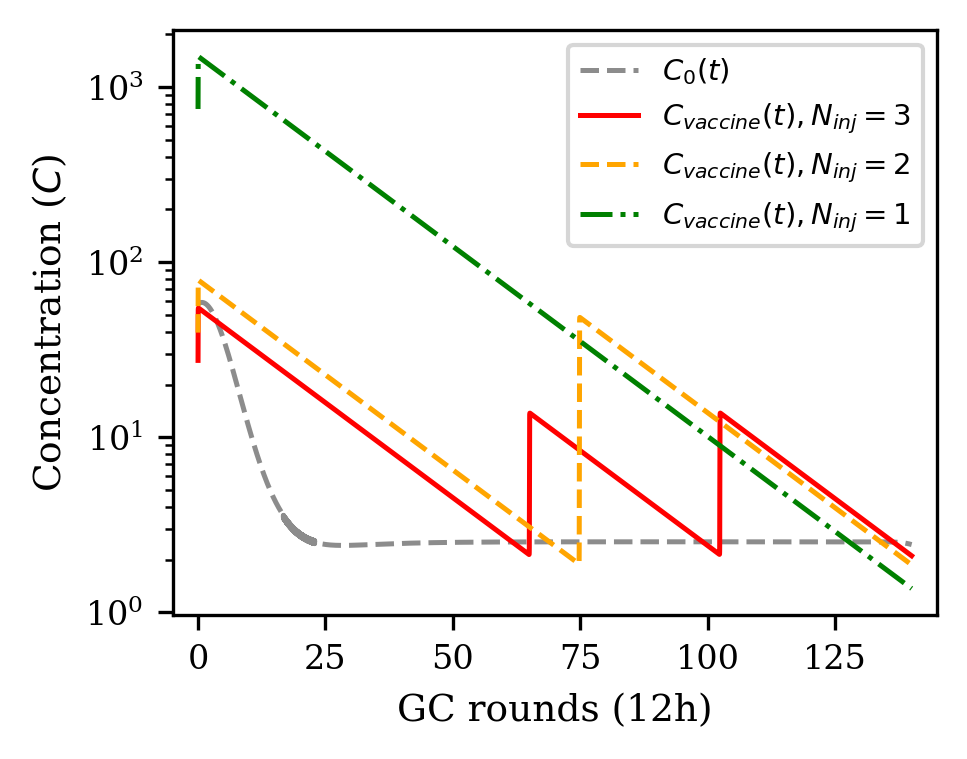

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# 1. Setup Plotting Style (Matching your template)
# ---------------------------------------------------------
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.markersize": 4,
    "figure.figsize": (3.4, 2.6),  # ≈8.6 cm × 6.6 cm
    "figure.dpi": 300,
    "font.family": "serif",        # Often preferred in papers
})

# ---------------------------------------------------------
# 2. Extract Data from Optimization Result
# ---------------------------------------------------------
# Assuming 'result' dictionary is available from the previous step
# and 't_data' and 'C_target' are the original inputs.



t_inj2 = result2['t_optimized']  # Injection times
C_inj2 = result2['C_optimized']  # Injection doses (optional to visualize)
C_sim2 = result2['C_simulated'].flatten() # Simulated Response

t_inj1 = result1['t_optimized']  # Injection times
C_inj1 = result1['C_optimized']  # Injection doses (optional to visualize)
C_sim1 = result1['C_simulated'].flatten() # Simulated Response

t_inj3 = result3['t_optimized']  # Injection times
C_inj3 = result3['C_optimized']  # Injection doses (optional to visualize)
C_sim3 = result3['C_simulated'].flatten() # Simulated Response

t_sim = times
C_ref = c_star

# ---------------------------------------------------------
# 3. Create Figure and Axes
# ---------------------------------------------------------
fig, ax = plt.subplots()

# ---------------------------------------------------------
# 4. Plot the Curves
# ---------------------------------------------------------

# Target C* (Dashed, Lighter Blue)
ax.plot(t_sim, C_ref, 
        label=r"$C_0(t)$", 
        color='grey',       # Soft Blue
        linestyle='--', 
        linewidth=1.2,
        alpha=0.9)

# Simulated C (Solid, Darker/Rich Blue)
ax.plot(t_sim, C_sim3, 
        label=r"$C_{vaccine}(t), N_{inj}=3$",
        color='red',       # Navy Blue
        linestyle='-', 
        linewidth=1.2)

ax.plot(t_sim, C_sim2, 
        label=r"$C_{vaccine}(t), N_{inj}=2$",
        color='orange',       # Navy Blue
        linestyle='--', 
        linewidth=1.2)


ax.plot(t_sim, C_sim1, 
        label=r"$C_{vaccine}(t), N_{inj}=1$",
        color='green',       # Navy Blue
        linestyle='-.', 
        linewidth=1.2)


# ---------------------------------------------------------
# 5. Add Injection Lines
# ---------------------------------------------------------
# Loop to plot lines, but only add label to legend once
# for i, t_val in enumerate(t_inj):
#     label = "Injection" if i == 0 else None
#     ax.axvline(x=t_val, 
#                color='black', # Nice Red
#                linestyle=':', 
#                linewidth=1.0, 
#                label=label)

# Optional: Add small triangles at the top to emphasize injection timing
# ax.plot(t_inj, [ax.get_ylim()[1]]*len(t_inj), 
#         marker='v', color='#D0021B', linestyle='None', markersize=3, clip_on=False)

# ---------------------------------------------------------
# 6. Formatting & Labels
# ---------------------------------------------------------
ax.set_xlabel("GC rounds (12h)")
ax.set_ylabel(r"Concentration ($C$)")
ax.set_xlim(t_sim[0], t_sim[-1])
# ax.set_ylim(bottom=0)  # Concentration cannot be negative
plt.yscale("log")  # Log scale for better visibility of differences

# Ticks pointing inwards (Your preference)
# ax.tick_params(direction="in", top=True, right=True)
ax.grid(False)

# Legend (No frame, best location)
ax.legend(frameon=True, loc='best', fontsize=7)

# ---------------------------------------------------------
# 7. Final Output
# ---------------------------------------------------------
fig.tight_layout()
plt.xlim(-5, 145)

plt.show()

# Optional: Save
# fig.savefig("optimization_result.pdf", format='pdf', bbox_inches='tight')

In [52]:
get_C_star_vacc1 = make_get_C_from_cstar(times, C_sim1)
get_C_star_vacc2 = make_get_C_from_cstar(times, C_sim2)
get_C_star_vacc3 = make_get_C_from_cstar(times, C_sim3)

#save as csv
# df_vacc = pd.DataFrame({"time": times, "C_vaccine_Ninj3": C_sim3, "C_vaccine_Ninj2": C_sim2, "C_vaccine_Ninj1": C_sim1})
# df_vacc.to_csv("optimized_vaccine_concentration.csv", index=False)


In [53]:


fp_ctx_mean = run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=lambda t,v:C_ref.mean(),
    T=T,
    verbose=False
)

fp_ctx_fixed = run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=lambda t,v:170,
    T=T,
    verbose=False
)

fp_ctx_opt_vacc1 = run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=get_C_star_vacc1,
    T=T,
    verbose=False
)

fp_ctx_opt_vacc2 = run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=get_C_star_vacc2,
    T=T,
    verbose=False
)

fp_ctx_opt_vacc3 = run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=get_C_star_vacc3,
    T=T,
    verbose=False
)

fp_ctx_opt = run_fp(
    get_S=lambda t: np.array([[1.0]]),  # 2D shape space: h₁ and h₂
    get_C=get_C_star,
    T=T,
    verbose=False
)

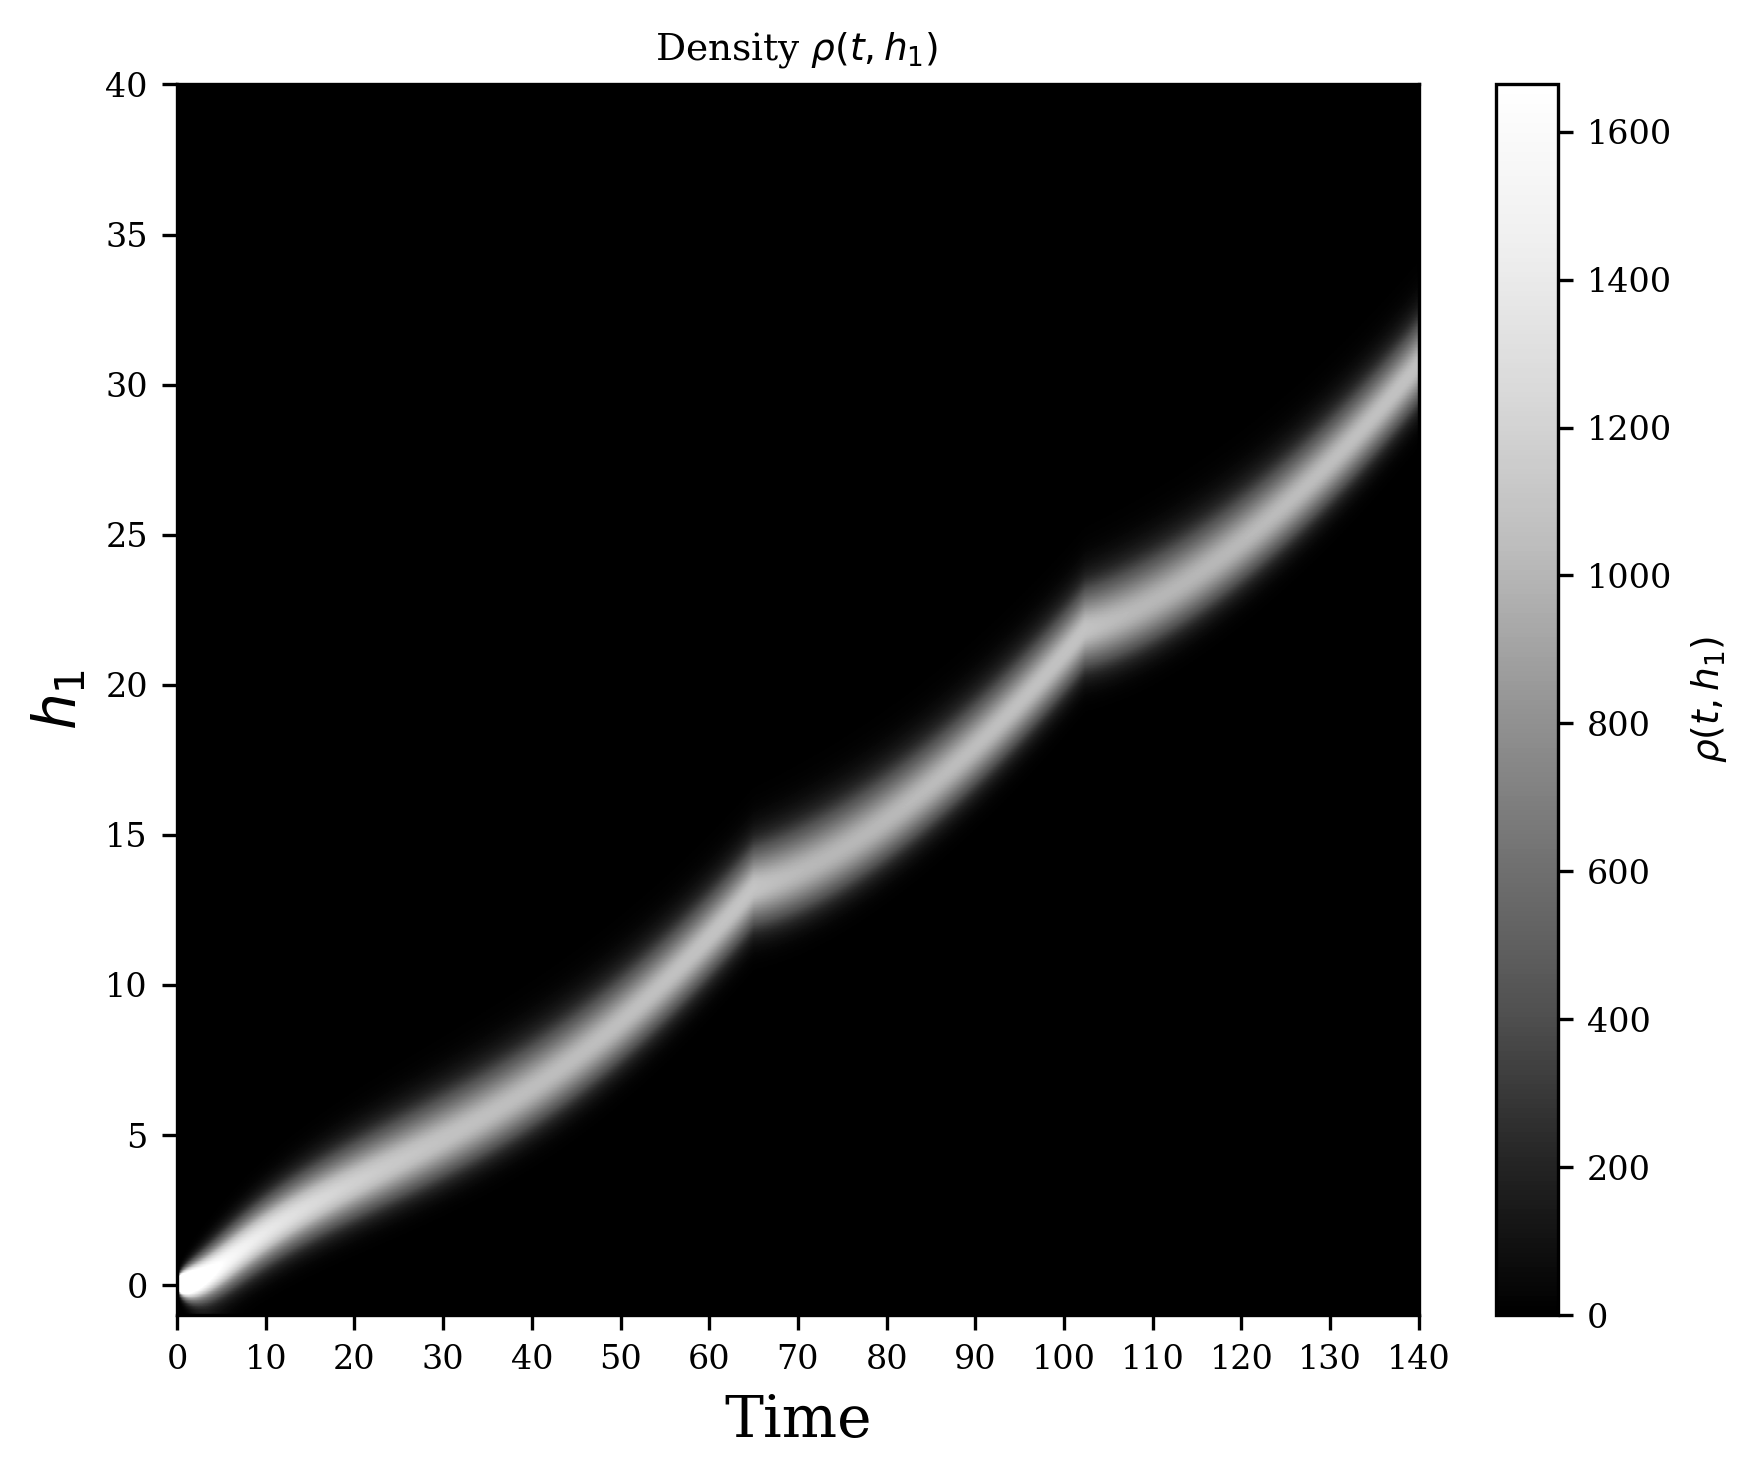

In [54]:
plot_fp_density_time_dim(fp_ctx_opt_vacc3, sol=None, disp_step=10, cmap="Greys_r")

In [55]:
def _marginal_h1_pdf(fp_ctx):
    """
    Return (h1_axis, pdf_h1) for the LAST snapshot in fp_ctx where 
    the population has at least 2000 individuals. Works for N_h >= 1 
    by integrating out other h-dims.
    """
    axes = fp_ctx["axes"]               # tuple/list of 1D arrays
    N_h  = len(axes)
    h1_axis = axes[0]
    d_h = h1_axis[1] - h1_axis[0]
    
    # Calculate the N-dimensional volume element
    dH = d_h ** N_h

    # Iterate backwards through time to find the correct snapshot
    rho_stack = fp_ctx["rho_t"]
    rho_alive = rho_stack[0]            # Fallback to initial state
    
    for i in range(len(rho_stack) - 1, -1, -1):
        current_population = rho_stack[i].sum() * dH
        if current_population >= 1250: 
            rho_alive = rho_stack[i]
            print(f"Selected snapshot index: {i}, Population: {current_population:.2f}")
            break

    if N_h == 1:
        rho1 = rho_alive.copy()
    else:
        # integrate out h2..hN with Riemann sum
        rho1 = rho_alive.sum(axis=tuple(range(1, N_h))) * (d_h ** (N_h - 1))

    # Keep as raw marginal density to match the histogram's rho_eps scale
    pdf = rho1 
        
    return h1_axis, pdf

In [56]:
def _marginal_last(fp_ctx):
    """
    Return (h1_axis, pdf_h1) for the snapshot in fp_ctx where 
    the total density above h_c is maximized. Works for N_h >= 1 
    by integrating out other h-dims.
    """
    axes = fp_ctx["axes"]               # tuple/list of 1D arrays
    N_h  = len(axes)
    h1_axis = axes[0]
    d_h = h1_axis[1] - h1_axis[0]
    
    # Calculate the N-dimensional volume element

    rho_stack = fp_ctx["rho_t"]
    
    # Boolean mask for the region strictly above h_c on the h1 axis
    
    best_index = -1
    
 

    # Select the snapshot with the maximum density above h_c
    rho_alive = rho_stack[best_index]

    if N_h == 1:
        rho1 = rho_alive.copy()
    else:
        # integrate out h2..hN with Riemann sum
        rho1 = rho_alive.sum(axis=tuple(range(1, N_h))) * (d_h ** (N_h - 1))

    # Keep as raw marginal density to match the histogram's rho_eps scale
    pdf = rho1 
        
    return h1_axis, pdf

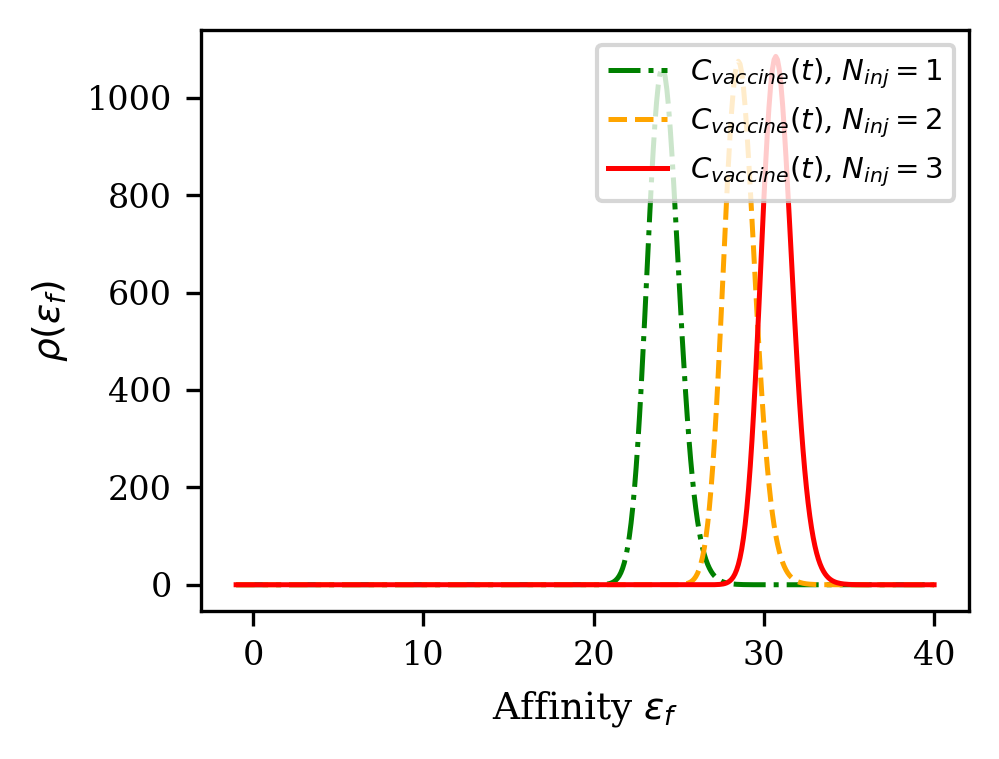

In [57]:

import numpy as np
import matplotlib.pyplot as plt


# --- get marginals for each schedule ---
h1_opt,   pdf_opt   = _marginal_last(fp_ctx_opt)
h1_mean,  pdf_mean  = _marginal_last(fp_ctx_mean)
h1_fixed, pdf_fixed = _marginal_last(fp_ctx_fixed)
h1_opt_vacc1, pdf_opt_vacc1 = _marginal_last(fp_ctx_opt_vacc1)
h1_opt_vacc2, pdf_opt_vacc2 = _marginal_last(fp_ctx_opt_vacc2)
h1_opt_vacc3, pdf_opt_vacc3 = _marginal_last(fp_ctx_opt_vacc3)

# sanity: same h1 grid
assert np.allclose(h1_opt, h1_mean) and np.allclose(h1_opt, h1_fixed), "h1 grids differ."

# --- plot ---
import matplotlib.pyplot as plt

# 1. Apply your preferred formatting style
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.markersize": 4,
    "figure.figsize": (3.4, 2.6),  # ≈8.6 cm × 6.6 cm
    "figure.dpi": 300,
})

# 2. Create Figure and Axes
fig, ax = plt.subplots()

# 3. Plot the data
# Using different linestyles helps distinguish curves in small/B&W figures
# ax.plot(h1_opt,   pdf_opt,   label=r"$C_0(t)$",               linestyle='-',  linewidth=1.2)
# ax.plot(h1_mean,  pdf_mean,  label=r"$\langle C_0(t)\rangle_t$", linestyle='--', linewidth=1.2, color='blue')
ax.plot(h1_opt_vacc1, pdf_opt_vacc1, label=r"$C_{vaccine}(t)$, $N_{inj}=1$",                linestyle='-.',  linewidth=1.2, color='green')
ax.plot(h1_opt_vacc2, pdf_opt_vacc2, label=r"$C_{vaccine}(t)$, $N_{inj}=2$",                linestyle='--',  linewidth=1.2, color='orange')
ax.plot(h1_opt_vacc3, pdf_opt_vacc3, label=r"$C_{vaccine}(t)$, $N_{inj}=3$",                linestyle='-',  linewidth=1.2, color='red')

# 4. Set Limits and Labels
# ax.set_xlim(2, 14)
ax.set_xlabel(r"Affinity $\epsilon_f$")
ax.set_ylabel(r"$\rho(\epsilon_f)$")
# ax.set_title(r"Marginal density of $h_1$")

# 5. Apply aesthetic preferences (ticks in, no grid)
# ax.tick_params(direction="in", top=True, right=True) # Added top/right ticks which usually accompany 'in'
ax.grid(False)

# 6. Legend and Layout
# frameon=False usually looks cleaner in small academic plots
ax.legend(frameon=True, loc='upper right', fontsize=7)


fig.tight_layout()
plt.show()

